In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    homogeneity_score,
    completeness_score,
    v_measure_score,
)

data = pd.read_csv("horse_colic_normalized.csv", delimiter=",")

target_col = "outcome"

data = data.dropna(subset=[target_col])

data.head()

,surgery,age,hospital_number,rectal_temperature,pulse,respiratory_rate,temperature_of_extremities,peripheral_pulse,mucous_membranes,capillary_refill_time,...,packed_cell_volume,total_protein,abdominocentesis_appearance,abdominocentesis_total_protein,outcome,lesion_site,lesion_type,lesion_subtype,cp_data,surgical_lesion
0,2.0,1,530101,38.5,66.0,28.0,3.0,3.0,NaN,2.0,...,45.0,8.4,NaN,NaN,2.0,11300,0,0,2,2
1,1.0,1,534817,39.2,88.0,20.0,NaN,NaN,4.0,1.0,...,50.0,85.0,2.0,2.0,3.0,2208,0,0,2,2
2,2.0,1,530334,38.3,40.0,24.0,1.0,1.0,3.0,1.0,...,33.0,6.7,NaN,NaN,1.0,0,0,0,1,2
3,1.0,9,5290409,39.1,164.0,84.0,4.0,1.0,6.0,2.0,...,48.0,7.2,3.0,5.3,2.0,2208,0,0,1,1
4,2.0,1,530255,37.3,104.0,35.0,NaN,NaN,6.0,2.0,...,74.0,7.4,NaN,NaN,2.0,4300,0,0,2,2


In [2]:
print('Информация о столбцах:')
print(data.info())

print('\nКоличество пропусков по столбцам:')
print(data.isna().sum())

print(f'\nРаспределение целевого столбца {target_col}:')
print(data[target_col].value_counts())

Информация о столбцах:
<class 'pandas.core.frame.DataFrame'>
Index: 366 entries, 0 to 367
Data columns (total 28 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   surgery                         366 non-null    float64
 1   age                             366 non-null    int64  
 2   hospital_number                 366 non-null    int64  
 3   rectal_temperature              297 non-null    float64
 4   pulse                           340 non-null    float64
 5   respiratory_rate                295 non-null    float64
 6   temperature_of_extremities      302 non-null    float64
 7   peripheral_pulse                283 non-null    float64
 8   mucous_membranes                318 non-null    float64
 9   capillary_refill_time           328 non-null    float64
 10  pain                            303 non-null    float64
 11  peristalsis                     315 non-null    float64
 12  abdominal_distensi

In [3]:
X = data.drop(columns=[target_col]).copy()
y_true = data[target_col].copy()

X = X.fillna(X.median())

scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)

print(f'Количество признаков для кластеризации: {X.shape[1]}')
print(f'Количество объектов: {X.shape[0]}')
print('Форма массива:', scaled_data.shape)

Количество признаков для кластеризации: 27
Количество объектов: 366
Форма массива: (366, 27)


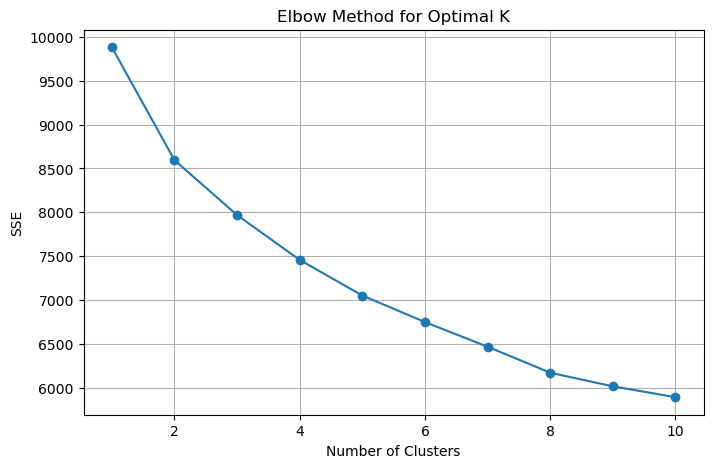

In [4]:
max_clusters = 10

sse = []

for k in range(1, max_clusters + 1):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_data)

    sse.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, max_clusters + 1), sse, marker='o')

plt.xlabel('Number of Clusters')
plt.ylabel('SSE')
plt.title('Elbow Method for Optimal K')

plt.grid(True)
plt.show()

In [5]:
metrics_rows = []

for k in range(2, max_clusters + 1):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = model.fit_predict(scaled_data)

    row = {
        'k': k,
        'inertia': model.inertia_,
        'silhouette': silhouette_score(scaled_data, labels_k),
        'calinski_harabasz': calinski_harabasz_score(scaled_data, labels_k),
        'davies_bouldin': davies_bouldin_score(scaled_data, labels_k),
        'ARI': adjusted_rand_score(y_true, labels_k),
        'NMI': normalized_mutual_info_score(y_true, labels_k),
        'homogeneity': homogeneity_score(y_true, labels_k),
        'completeness': completeness_score(y_true, labels_k),
        'v_measure': v_measure_score(y_true, labels_k),
    }

    metrics_rows.append(row)

metrics_table = pd.DataFrame(metrics_rows)
metrics_table.round(4)

,k,inertia,silhouette,calinski_harabasz,davies_bouldin,ARI,NMI,homogeneity,completeness,v_measure
0,2,8595.2298,0.1362,54.4935,2.4546,0.1679,0.1189,0.1039,0.1390,0.1189
1,3,7969.5190,0.1345,43.5554,2.1760,0.1414,0.1511,0.1510,0.1512,0.1511
2,4,7458.0225,0.1083,39.2186,2.3713,0.1130,0.1436,0.1719,0.1232,0.1436
3,5,7052.3786,0.1125,36.2109,1.9229,0.1115,0.1465,0.1763,0.1253,0.1465
4,6,6749.8255,0.1212,33.4107,1.8300,0.1261,0.1417,0.1797,0.1170,0.1417
5,7,6469.0599,0.1180,31.5668,1.7812,0.1069,0.1355,0.1791,0.1090,0.1355
6,8,6172.7316,0.1188,30.7324,1.6807,0.1041,0.1343,0.1827,0.1062,0.1343
7,9,6017.9582,0.0949,28.6531,1.8601,0.0491,0.1317,0.1932,0.0999,0.1317
8,10,5893.6231,0.0884,26.7683,2.0058,0.0597,0.1251,0.1945,0.0922,0.1251


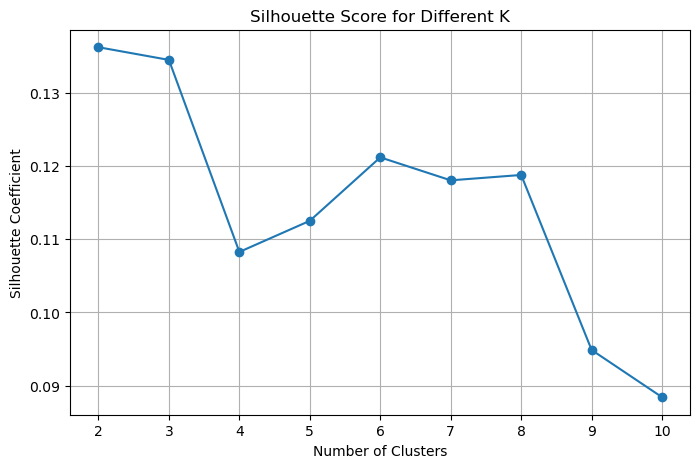

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(metrics_table['k'], metrics_table['silhouette'], marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Coefficient')
plt.title('Silhouette Score for Different K')
plt.grid(True)
plt.show()

best_k_by_silhouette = int(metrics_table.loc[metrics_table['silhouette'].idxmax(), 'k'])

In [7]:
optimal_k = 3

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(scaled_data)

data['cluster'] = cluster_labels

print(data['cluster'].value_counts().sort_index())

cluster
0    159
1     30
2    177
Name: count, dtype: int64


In [8]:
centers_original_scale = scaler.inverse_transform(
    kmeans.cluster_centers_
)

centers_df = pd.DataFrame(
    centers_original_scale,
    columns=X.columns
)

centers_df.index = [
    f'Cluster {i}'
    for i in range(optimal_k)
]

print(centers_df.round(3))

           surgery    age  hospital_number  rectal_temperature    pulse  \
Cluster 0    1.648  1.000       769950.704              38.053   51.434   
Cluster 1    1.267  8.467      4814441.500              38.507  111.467   
Cluster 2    1.232  1.000       798949.672              38.133   79.797   

           respiratory_rate  temperature_of_extremities  peripheral_pulse  \
Cluster 0            24.075                       2.038             1.132   
Cluster 1            53.267                       2.467             1.900   
Cluster 2            31.452                       2.853             2.277   

           mucous_membranes  capillary_refill_time  ...  abdomen  \
Cluster 0             2.038                  1.057  ...    3.277   
Cluster 1             3.033                  1.200  ...    3.833   
Cluster 2             3.554                  1.475  ...    4.305   

           packed_cell_volume  total_protein  abdominocentesis_appearance  \
Cluster 0              40.487         26

In [9]:
result = data.copy()

result['cluster'] = cluster_labels

print('Количество объектов в каждом кластере:')
print(result['cluster'].value_counts().sort_index())

print('\nСравнение outcome и cluster:')

print(
    pd.crosstab(
        result['outcome'],
        result['cluster'],
        rownames=['outcome'],
        colnames=['cluster']
    )
)

print(result.head())

Количество объектов в каждом кластере:
cluster
0    159
1     30
2    177
Name: count, dtype: int64

Сравнение outcome и cluster:
cluster    0   1   2
outcome             
1.0      139  15  71
2.0        7  14  68
3.0       13   1  38
   surgery  age  hospital_number  rectal_temperature  pulse  respiratory_rate  \
0      2.0    1           530101                38.5   66.0              28.0   
1      1.0    1           534817                39.2   88.0              20.0   
2      2.0    1           530334                38.3   40.0              24.0   
3      1.0    9          5290409                39.1  164.0              84.0   
4      2.0    1           530255                37.3  104.0              35.0   

   temperature_of_extremities  peripheral_pulse  mucous_membranes  \
0                         3.0               3.0               NaN   
1                         NaN               NaN               4.0   
2                         1.0               1.0               3.0   
3 

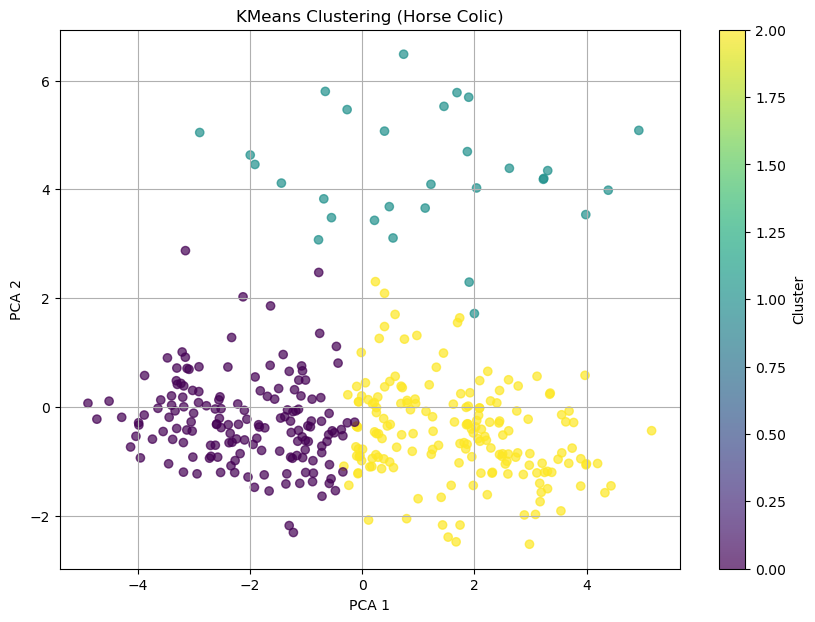

In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(scaled_data)

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_labels,
    cmap='viridis',
    alpha=0.7
)

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')

plt.title('KMeans Clustering (Horse Colic)')

plt.colorbar(scatter, label='Cluster')

plt.grid(True)
plt.show()

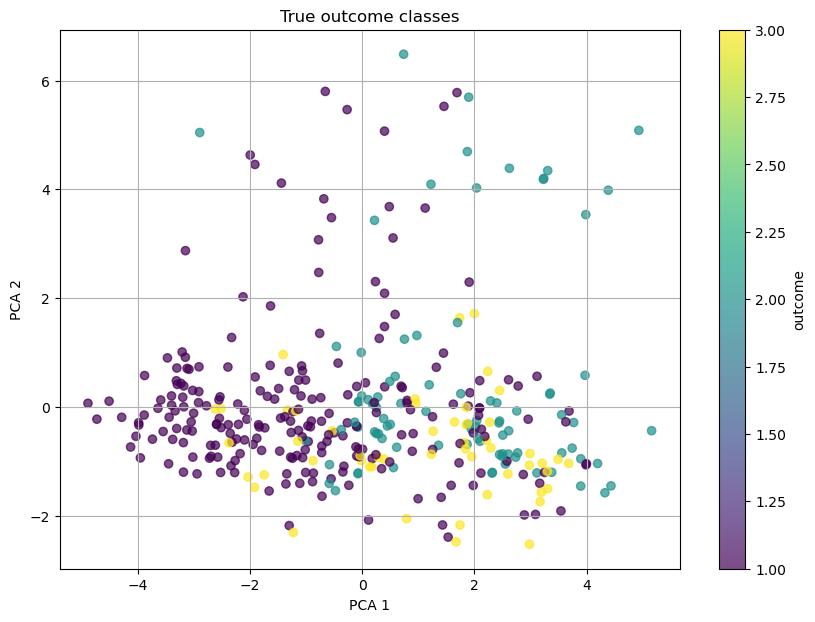

In [11]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y_true,
    cmap='viridis',
    alpha=0.7
)

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('True outcome classes')
plt.colorbar(scatter, label=target_col)
plt.grid(True)
plt.show()